In [17]:
%load_ext autoreload

%autoreload 2

In [18]:
from typing import Dict, List, Optional, Tuple, Union, Any, Callable, Mapping
import pandas as pd
import pickle
import numpy as np
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (f1_score, matthews_corrcoef, balanced_accuracy_score, roc_auc_score, cohen_kappa_score, auc, precision_recall_curve)
from rdkit.Chem import rdFingerprintGenerator
import matplotlib.pyplot as plt
import umap

In [15]:
def fin(df, radius, fpSize):
    fingerprints = []
    onbits_list = []
    fp_generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=fpSize)
    for i, mol in enumerate(df["ROMol"]):
        try:
            fp = fp_generator.GetFingerprint(mol)
            # 1になっているビットの位置を取得
            onbits = list(fp.GetOnBits())
            onbits_list.append(onbits)
            
            # NumPy配列も必要なら
            fp_np = fp_generator.GetFingerprintAsNumPy(mol)
            fingerprints.append(fp_np)

        except Exception as e:
            print(f"Error processing molecule {i}: {e}")
            continue
    return np.array(fingerprints), onbits_list

def add_vectors(fp_list: List[List[int]], model: Doc2Vec) -> List[np.ndarray]:
    """Combine document vectors based on fingerprints
    
    Args:
        fp_list: List of fingerprint lists, where each fingerprint is represented as a list of indices
        model: Trained Doc2Vec model containing document vectors
        
    Returns:
        List of compound vectors as numpy arrays
    """
    compound_vec = []
    for i in fp_list:
        fingerprint_vec = 0
        for j in i:
            fingerprint_vec += model.dv.vectors[j]
        compound_vec.append(fingerprint_vec)
    return compound_vec

def evaluate_category(df, X_vec, y, lightgbm_model):
    li =[]
    predictions = np.zeros(len(df))
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    for train_idx, test_idx in skf.split(range(len(y)), y):
        X_train, X_test = X_vec[train_idx], X_vec[test_idx]
        y_train_fold, y_test_fold = y[train_idx], y[test_idx]
        lightgbm_model.fit(X_train, y_train_fold)
        y_pred = lightgbm_model.predict(X_test)
        li.append(f1_score(y_test_fold, y_pred))
        predictions[test_idx] = y_pred
    print(np.mean(li))

    return predictions

def make_doc2vector(model_path, df: pd.DataFrame, tag_list: List[List[int]]) -> np.ndarray:

    model = Doc2Vec.load(model_path)
    compound_vec = add_vectors(tag_list, model)
    X_vec = np.array([compound_vec[i] for i in range(len(df))])
    return X_vec

def main(df, X_vec, lightgbm_model):
        
    # Define categories to evaluate
    categories = [
        'antioxidant', 'anti_inflammatory_agent', 'allergen', 'dye', 'toxin', 
        'flavouring_agent', 'agrochemical', 'volatile_oil', 'antibacterial_agent', 'insecticide'
    ]
    fpdoc_list = []
    # Evaluate each category
    for category in categories:
        y = np.array([1 if i == category else 0 for i in df[category]])
        a = evaluate_category(df, X_vec, y, lightgbm_model)
        fpdoc_list.append(a)
    return fpdoc_list

トレインとテストデータの分布確認

In [107]:
def train_test_plot(all_data, test_data, doc2vec_model, n_neighbors=30, min_dist=0.5, metric="cosine"):
    names_tb = pd.DataFrame({"NAME" : [i[0] for i in all_data["compounds"]], "category": [1 if i in list(test_data["inchikey"]) else 0 for i in all_data["inchikey"]]})
    # finger_list = list(all_data["fp_3_4096"])
    # compound_vec = add_vectors(finger_list, doc2vec_model)
    # vec = np.array(compound_vec)
    ecfp = fin(all_data, 3, 4096)[0]
    Umap = umap.UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=min_dist, metric=metric, random_state=0)
    digits_tsne = Umap.fit_transform(ecfp)
    dim_df = pd.DataFrame(digits_tsne, columns=["x", "y"])
    index_tb = pd.concat([names_tb, dim_df], axis=1)
    plt.rcParams["figure.subplot.bottom"] = 0.1
    # 0の点を先に描画
    mask_0 = index_tb["category"] == 0
    plt.scatter(index_tb[mask_0]["x"], index_tb[mask_0]["y"], c='blue', s=9, alpha=0.7, label='Training data')
    # 1の点を後で描画
    mask_1 = index_tb["category"] == 1
    plt.scatter(index_tb[mask_1]["x"], index_tb[mask_1]["y"], c='red', s=9, alpha=1, label='Test data')
    plt.xlabel(None)
    plt.ylabel(None)
    plt.legend()
    plt.show()
    return None

/opt/anaconda3/envs/FpDoc2Vec/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


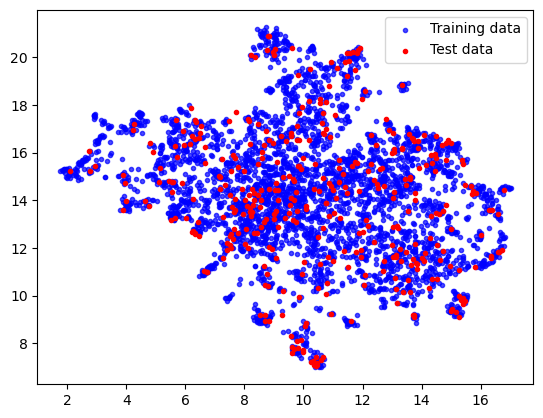

In [108]:
if __name__ == "__main__":
    with open("data/10genre_all.pkl", "rb") as f:
        df = pickle.load(f)
    with open("data/test_df2.pkl", "rb") as f:
        test_df = pickle.load(f)
    model = Doc2Vec.load("train_df_doc2vec.model")
    train_test_plot(df, test_df, model)

正例の中のトレイン、テストの分布確認

In [109]:
def train_test_within_positive(df, test_df, model):
   categories = ["antioxidant",
      "anti_inflammatory_agent", "allergen", "dye", "toxin", "flavouring_agent",
      "agrochemical", "volatile_oil", "antibacterial_agent", "insecticide"]
   categories2 = ["\"antioxidant\"",
      "\"anti-inflammatory agent\"", "\"allergen\"", "\"dye\"", "\"toxin\"", "\"flavouring agent\"",
      "\"agrochemical\"", "\"volatile oil\"", "\"antibacterial agent\"", "\"insecticide\""]
   # finger_list = list(df["fp_3_4096"])
   # compound_vec = add_vectors(finger_list, model)
   # vec = np.array(compound_vec)
   ecfp = fin(df, 3, 4096)[0]
   Umap = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.5, metric="cosine", random_state=0)
   digits_tsne = Umap.fit_transform(ecfp)
   dim_df = pd.DataFrame(digits_tsne, columns=["x", "y"])
   df = pd.concat([df, dim_df], axis=1)
   fig, axes = plt.subplots(2, 5, figsize=(20, 8))
   axes = axes.flatten()
   for idx, category in enumerate(categories):
      ax = axes[idx]
      category_df = df[df[category] == category]
      category_df = category_df.copy()
      category_df["NAME"] = [i[0] for i in category_df["compounds"]]
      category_df["category"] = [1 if i in list(test_df["inchikey"]) else 0 for i in category_df["inchikey"]]
      index_tb = category_df
      # 0の点を先に描画
      mask_0 = index_tb["category"] == 0
      ax.scatter(index_tb[mask_0]["x"], index_tb[mask_0]["y"], c="blue", s=9, alpha=0.6, label="Traing data")
      # 1の点を後で描画
      mask_1 = index_tb["category"] == 1
      ax.scatter(index_tb[mask_1]["x"], index_tb[mask_1]["y"], c="red", s=9, alpha=1, label="Test data")
      ax.set_title(categories2[idx], fontsize=21, fontweight="bold")
      ax.set_xlabel(None)
      ax.set_ylabel(None)
      # ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
      ax.tick_params(axis="both", which="major", labelsize=8)
   plt.tight_layout()
   # plt.savefig("fpdoc2vec_umap.png", dpi=300, bbox_inches="tight")
   plt.show()

/opt/anaconda3/envs/FpDoc2Vec/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


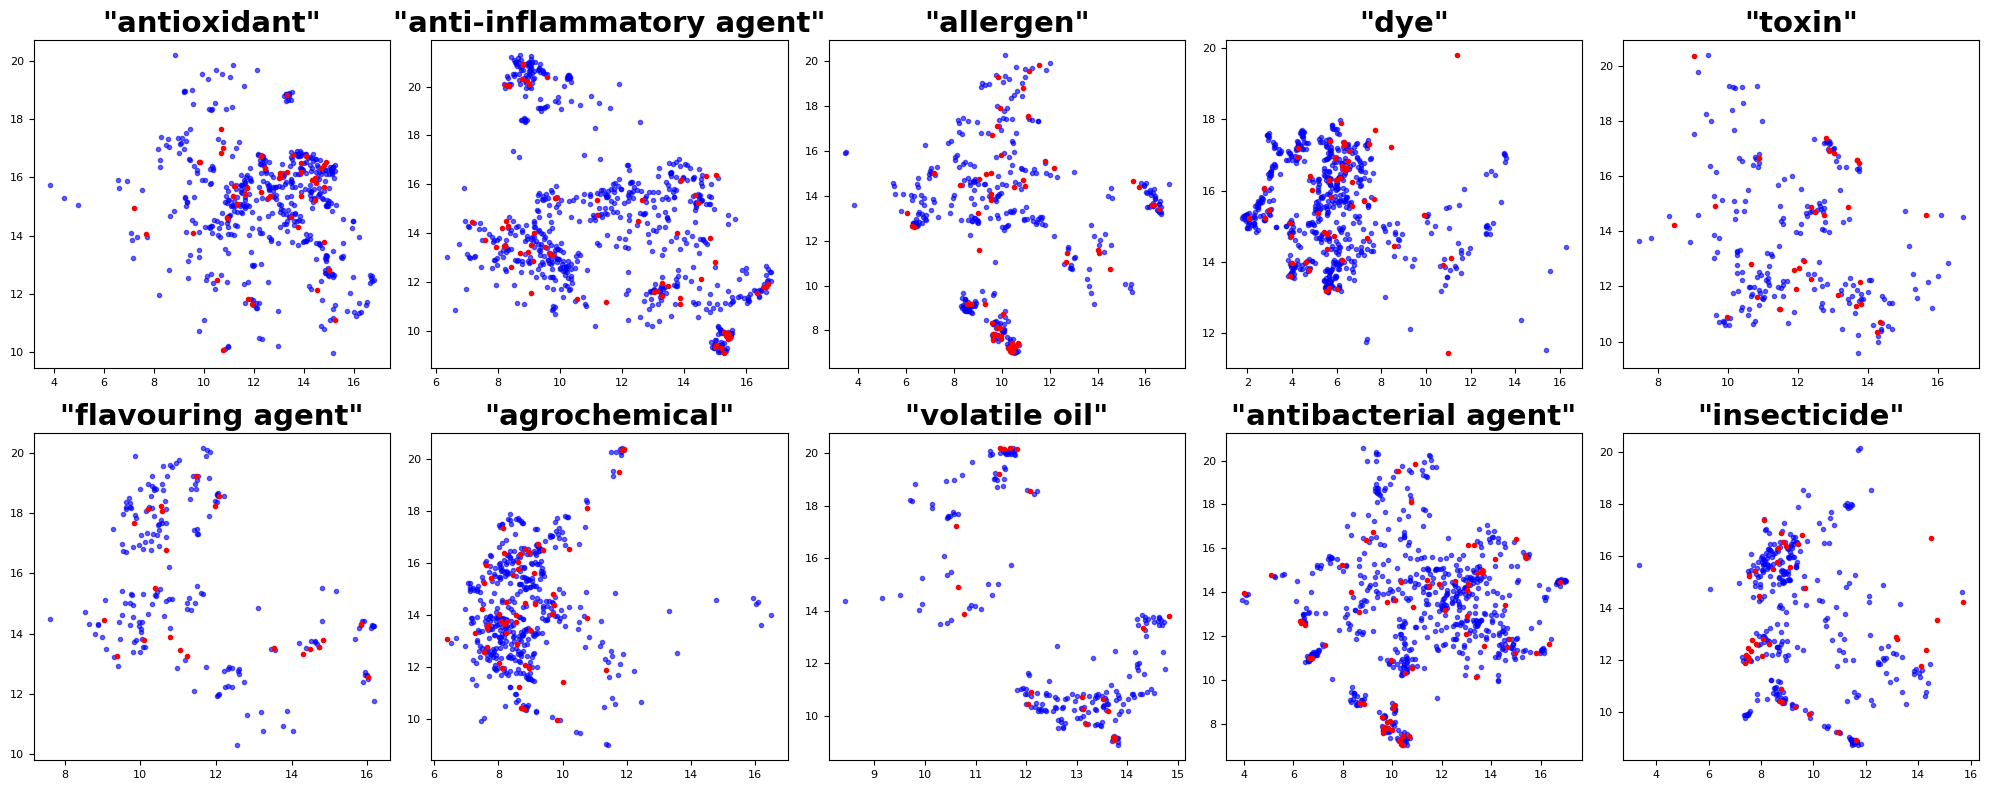

In [110]:
if __name__ == "__main__":
    with open("data/10genre_all.pkl", "rb") as f:
        df = pickle.load(f)
    with open("data/test_df2.pkl", "rb") as f:
        test_df = pickle.load(f)
    model = Doc2Vec.load("train_df_doc2vec.model")
    train_test_within_positive(df, test_df, model)

In [4]:
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

gbm_params: Dict[str, Any] = {
    "boosting_type": "dart",
    "num_leaves": 48,
    "max_depth": 5,
    "learning_rate": 0.04166324251391809,
    "n_estimators": 736,
    "class_weight": "balanced",
    "min_split_gain": 0.009346925180781129,
    "min_child_weight": 0.0007929549087822909,
    "min_child_samples": 37,
    "reg_alpha": 1.757104268180148,
    "reg_lambda": 1.463369722508726,
    "feature_fraction": 0.50163362868711,
    "feature_fraction_bynode": 0.8321043377994284,
    "subsample": 0.6974385909748512,
    "colsample_bytree": 0.6568268046410831,
    "subsample_freq": 5,
    "drop_rate": 0.24668126335938073,
    "max_drop": 28,
    "skip_drop": 0.5591506516119614,
    "uniform_drop": True,
    "xgboost_dart_mode": True,
    "objective": "binary",
    "random_state": 0,
    "verbose": -1,
    "force_col_wise": True
}

# Create classifier
lightgbm_model = lgb.LGBMClassifier(**gbm_params)

input_path = "data/train_df2.pkl"
with open(input_path, "rb") as f:
    train_df = pickle.load(f)

# FP Doc2Vec approach
model_path = "train_df_doc2vec.model"
bit_list = fin(train_df, 3, 4096)[1]
X_vec = make_doc2vector(model_path, train_df, bit_list)
fpdoc_list = main(train_df, X_vec, lightgbm_model)

0.7221319778859124
0.7467746235518791
0.6912898979130322
0.9385639376334233
0.6287459557985874
0.7306613370362036
0.8155121280984631
0.8023856634836968
0.6956427669841374
0.7729619861371464


!!! NAME doc2vec !!!

In [27]:
def make_name2vector(df: pd.DataFrame, purpose_description, doc2vec_param) -> np.ndarray:
    """Convert to compound vectors using NameDoc2Vec model
    
    Args:
        model_path: Path to the saved NameDoc2Vec model file
        df: DataFrame containing compound data
        
    Returns:
        NumPy array of document vectors with shape (len(df), vector_size)
    """
    corpus = df[purpose_description].tolist()#変更
    tag_list = [i[0] for i in df["compounds"]]

    tagged_documents = [TaggedDocument(words=corpus, tags=[tag_list[i]]) #変更
        for i, corpus in enumerate(corpus)]
    model = Doc2Vec(tagged_documents, **doc2vec_param)
    # model.save("train_df_namedoc2vec.model")
    X_vec = np.array([model.dv.vectors[i] for i in range(len(df))])

    return X_vec

In [6]:
doc2vec_param: Dict[str, Any] = {
    'vector_size': 150,
    'dm': 1,
    'window': 9,
    'min_count': 0,
    'alpha': 0.014996471116783728,
    'sample': 4.4713728630733355e-05,
    'epochs': 840,
    'negative': 12,
    'workers': 1,
    'seed': 0
}

input_path = "data/train_df2.pkl"
with open(input_path, "rb") as f:
    df = pickle.load(f)
    
X_vec = make_name2vector(df, "description_gensim", doc2vec_param)
namedoc_list = main(df, X_vec, lightgbm_model)

0.7671965214779315
0.7660120243499368
0.8154858581540173
0.9211018323633697
0.6794094990208336
0.7827436383626024
0.7903278754183274
0.855548446133812
0.7709361024248991
0.7786183354561267


!!! ECFP !!!

In [7]:
ecfp = fin(train_df, 3, 4096)[0]
ecfp_list = main(train_df, ecfp, lightgbm_model)

0.6015553790279262
0.6171355040298478
0.5490671296566296
0.8873814052298581
0.4221985080832538
0.5265515511075656
0.6617518947530117
0.6788680752941391
0.5740151262724584
0.5805888185768913


!!! Descriptor !!!

In [33]:
def make_descriptors(
    input_file: str, 
    train_df: pd.DataFrame, 
) -> Dict[str, Dict[str, float]]:

    # Load dataset
    with open(input_file, "rb") as f:
        df = pickle.load(f)
        
    # Split data into train and test sets
    train_df1 = df[df["inchikey"].isin(list(train_df["inchikey"]))]
    test_df1 = df.drop(train_df1.index)
    
    # Extract descriptor columns (from column 14 onward)
    train_desc = np.array(train_df1.iloc[:, 14:])
    test_desc = np.array(test_df1.iloc[:, 14:])

    return train_desc, test_desc

In [9]:
input_path = "data/10genre_32descriptor.pkl"
desc = make_descriptors(input_path, train_df)[0]
desc_list = main(train_df, desc, lightgbm_model)

0.6138146080055218
0.613516036639427
0.6402250736690641
0.8796194716786511
0.5048833396982317
0.654539083008385
0.732184162276743
0.7803529610407021
0.5713387482694917
0.6873294586272831


!!! データセット作成　!!!

In [10]:
input_path = "data/train_df2.pkl"
with open(input_path, "rb") as f:
    train_df = pickle.load(f)
categories = [
        'antioxidant', 'anti_inflammatory_agent', 'allergen', 'dye', 'toxin', 
        'flavouring_agent', 'agrochemical', 'volatile_oil', 'antibacterial_agent', 'insecticide'
    ]
result_df = pd.DataFrame({"NAME": [i[0] for i in train_df["compounds"]],
                   "inchikey": train_df["inchikey"].tolist(),
                   "smiles": train_df["smiles"].tolist(),
                   "description": train_df["description"].tolist()})

for i in range(len(categories)):
    category = categories[i]
    result_df[category] = [1 if i == category else 0 for i in train_df[category]]
    result_df[f"fp_doc2vec_{category}"] = fpdoc_list[i]
    result_df[f"namedoc_{category}"] = namedoc_list[i]
    result_df[f"ecfp_{category}"] = ecfp_list[i]
    result_df[f"desc_{category}"] = desc_list[i]

In [11]:
#スコアの追加
true_labels = np.array([result_df[cat] for cat in categories]).T
pred_columns = [f"fp_doc2vec_{category}" for category in categories]
pred_labels = np.array([result_df[col] for col in pred_columns]).T
scores = np.sum(true_labels == pred_labels, axis=1)
result_df["score"] = scores

In [12]:
bit_list = fin(train_df, 3, 4096)[1]
result_df["fp_3_4096"] = bit_list
result_df["len_fp"] = [len(fp) for fp in bit_list]

In [17]:
result_df["len_description"] = [len(sum(i,[])) for i in train_df["description_split"]]

In [18]:
result_df.to_csv("result_4compare.csv", index=False)

In [14]:
from rdkit.Chem import PandasTools
PandasTools.AddMoleculeColumnToFrame(result_df, molCol = 'IMAGE', smilesCol = 'smiles')
PandasTools.SaveXlsxFromFrame(result_df, "result_4compare.xlsx", molCol = 'IMAGE', size =(150,150))

[00:17:08] WARNING: not removing hydrogen atom without neighbors
[00:17:08] WARNING: not removing hydrogen atom without neighbors
[00:17:08] WARNING: not removing hydrogen atom without neighbors
[00:17:08] WARNING: not removing hydrogen atom without neighbors
[00:17:08] WARNING: not removing hydrogen atom without neighbors
[00:17:08] WARNING: not removing hydrogen atom without neighbors
[00:17:08] WARNING: not removing hydrogen atom without neighbors
[00:17:08] WARNING: not removing hydrogen atom without neighbors
[00:17:08] WARNING: not removing hydrogen atom without neighbors
[00:17:08] WARNING: not removing hydrogen atom without neighbors
[00:17:08] WARNING: not removing hydrogen atom without neighbors
[00:17:08] WARNING: not removing hydrogen atom without neighbors
[00:17:08] WARNING: not removing hydrogen atom without neighbors
[00:17:08] WARNING: not removing hydrogen atom without neighbors
[00:17:08] WARNING: not removing hydrogen atom without neighbors
[00:17:08] WARNING: not r

!!!!類似度評価!!!

In [4]:
from numpy.linalg import norm
from IPython.display import display
from rdkit.DataStructs import BulkTanimotoSimilarity
from rdkit import DataStructs

In [5]:
def get_categories(df: pd.DataFrame, idx: int) -> str:
    """化合物のカテゴリーを取得"""
    categories = [
        'antioxidant', 'anti_inflammatory_agent', 'allergen', 'dye', 'toxin',
        'flavouring_agent', 'agrochemical', 'volatile_oil', 'antibacterial_agent', 'insecticide'
    ]
    found_categories = []
    for cat in categories:
        if cat in df.columns and df.iat[idx, df.columns.get_loc(cat)] != 'No':
            found_categories.append(cat)
    return ', '.join(found_categories) if found_categories else 'No specific category'




def cosine_similarity(vec1: np.ndarray, vec2: np.ndarray) -> float:
    return np.dot(vec1, vec2) / (norm(vec1) * norm(vec2))


def calculate_similarities(df: pd.DataFrame, vectors: np.ndarray, target_compound: str) -> List[float]:
    try:
        # ターゲット化合物のインデックスを取得
        df["NAME"] = [df.iat[i, 0][0] for i in range(len(df))]
        target_indices = df[df["NAME"] == target_compound].index
        target_idx = target_indices[0]
        # ベクトル化で一括計算
        target_vector = vectors[target_idx]
        
        # 各ベクトルとの類似度を計算
        similarities = []
        for i, vector in enumerate(vectors):
            if i != target_idx:
                sim = cosine_similarity(vector, target_vector)
                similarities.append(sim)
            else:
                similarities.append(0)  # 自分自身は0      
        return similarities
        
    except IndexError:
        raise ValueError(f"化合物 '{target_compound}' がデータセットに見つかりません")

def similarity_output(input_path: str, compound_vec:np.ndarray, target_compound: str, n: int) -> None:

    # Load dataset
    with open(input_path, "rb") as f:
        df = pickle.load(f)
    
    # Add compound names as a separate column
    df["NAME"] = [df.iat[i, 0][0] for i in range(len(df))]
    
    # Calculate similarities to sucrose
    df[target_compound] = calculate_similarities(df, compound_vec, target_compound)
    
    # Get top n similar compounds
    sorted_df = df.sort_values(target_compound, ascending=False)
    
    # Return the top N compounds (excluding the target compound itself)
    top_similar = sorted_df.head(n)[['NAME', target_compound]]
    target_idx = df[df["NAME"] == target_compound].index[0]
    target_categories = get_categories(df, target_idx)
    print(f"Target compound '{target_compound}' categories: {target_categories}")

    # Display results in the same format as the previous code
    print(f"Top {n} most similar compounds to '{target_compound}':")
    for idx, row in top_similar.iterrows():
        compound_name = row['NAME']
        similarity_score = row[target_compound]
        categories = get_categories(df, idx)  # 追加: カテゴリー取得
        print(f"  {compound_name}: {similarity_score:.4f} (Categories: {categories})")  # 変更: カテゴリー表示
        display(df.iat[idx, 10])

In [7]:
with open("data/train_df2.pkl", "rb") as f:
    train_df = pickle.load(f)
model_path = "train_df_doc2vec.model"
bit_list = fin(train_df, 3, 4096)[1]
X_vec = make_doc2vector(model_path, train_df, bit_list)

In [8]:
a=calculate_similarities(train_df, X_vec, "sucrose")
len(a)

3533

3-methylbutanal, cis-caffeic acid

Target compound 'resveratrol' categories: antioxidant, toxin
Top 3 most similar compounds to 'resveratrol':
  cis-resveratrol: 1.0000 (Categories: antioxidant, toxin)


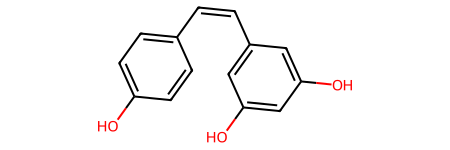

  (E,E)-1-bromo-2,5-bis-(4-hydroxystyryl)benzene: 0.8985 (Categories: dye)


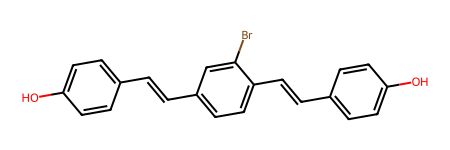

  quadrangularin A: 0.8472 (Categories: antioxidant)


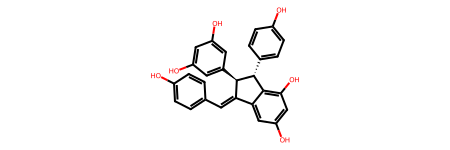

In [75]:
# Get fingerprints and load model
model_path = "train_df_doc2vec.model"
input_path = "data/train_df2.pkl"
bit_list = fin(train_df, 3, 4096)[1]
model = Doc2Vec.load(model_path)
    
# Generate compound vectors
compound_vec = add_vectors(bit_list, model)
similarity_output(input_path, compound_vec, "resveratrol", 3)

!!! Name Doc2vec !!!taurine

Target compound 'resveratrol' categories: antioxidant, toxin
Top 3 most similar compounds to 'resveratrol':
  cis-resveratrol: 0.7397 (Categories: antioxidant, toxin)


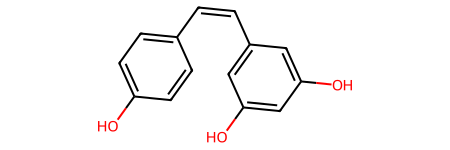

  (E)-trans-miyabenol C: 0.6607 (Categories: antioxidant)


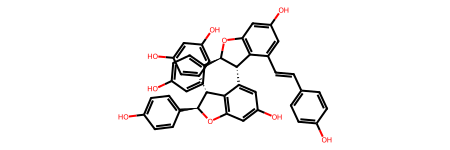

  quadrangularin A: 0.6468 (Categories: antioxidant)


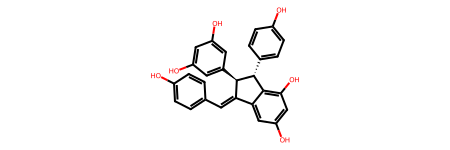

In [76]:
# Get fingerprints and load model
model_path = "train_df_namedoc2vec.model"
input_path = "data/train_df2.pkl"
model = Doc2Vec.load(model_path)
    
# Generate compound vectors
compound_vec = np.array([model.dv.vectors[i] for i in range(len(train_df))])
similarity_output(input_path, compound_vec, "resveratrol", 3)

!!! ECFP !!!

In [13]:
def fin2(df, radius, fpSize):
    fingerprint_objects = []  # この行を追加
    fp_generator = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=fpSize)
    for i, mol in enumerate(df["ROMol"]):
        try:
            fp = fp_generator.GetFingerprint(mol)
            fingerprint_objects.append(fp)  # この行を追加

        except Exception as e:
            print(f"Error processing molecule {i}: {e}")
            continue
    return fingerprint_objects  

def calculate_tanimoto_similarities(df: pd.DataFrame, fingerprint_objects: List, target_compound: str) -> List[float]:
    try:
        # ターゲット化合物のインデックスを取得
        df["NAME"] = [df.iat[i, 0][0] for i in range(len(df))]
        target_indices = df[df["NAME"] == target_compound].index
        target_idx = target_indices[0]
        
        # ターゲットのフィンガープリント
        target_fp = fingerprint_objects[target_idx]
        
        # BulkTanimotoSimilarityで一括計算
        similarities = BulkTanimotoSimilarity(target_fp, fingerprint_objects)
        
        # 自分自身は0に設定
        similarities[target_idx] = 0.0
                
        return similarities
        
    except IndexError:
        raise ValueError(f"化合物 '{target_compound}' がデータセットに見つかりません")
    
    
def tanimoto_similarity_output(input_path: str, fingerprint_objects: List, target_compound: str, n: int = 10) -> None:
    """谷本類似度の結果を出力"""
    # Load dataset
    with open(input_path, "rb") as f:
        df = pickle.load(f)
    
    # Add compound names as a separate column
    df["NAME"] = [df.iat[i, 0][0] for i in range(len(df))]
    df[target_compound] = calculate_tanimoto_similarities(df, fingerprint_objects, target_compound)
    
    # Get top n similar compounds
    sorted_df = df.sort_values(target_compound, ascending=False)
    top_similar = sorted_df.head(n)[['NAME', target_compound]]
    target_idx = df[df["NAME"] == target_compound].index[0]
    target_categories = get_categories(df, target_idx)
    # Display results with 10th column
    print(f"Target compound '{target_compound}' categories: {target_categories}")
    print(f"Top {n} most similar compounds to '{target_compound}' (Tanimoto similarity):")
    for idx, row in top_similar.iterrows():
        compound_name = row['NAME']
        similarity_score = row[target_compound]
        categories = get_categories(df, idx)  # 追加: カテゴリー取得
        print(f"  {compound_name}: {similarity_score:.4f} (Categories: {categories})")
        display(df.iat[idx, 10])

Target compound 'resveratrol' categories: antioxidant, toxin
Top 10 most similar compounds to 'resveratrol' (Tanimoto similarity):
  cis-resveratrol: 1.0000 (Categories: antioxidant, toxin)


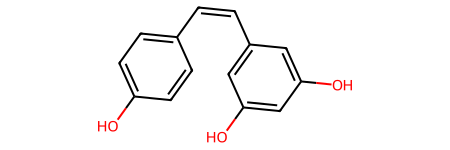

  pterostilbene: 0.5238 (Categories: antioxidant, anti_inflammatory_agent)


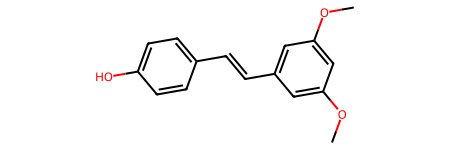

  (E,E)-1-bromo-2,5-bis-(4-hydroxystyryl)benzene: 0.4255 (Categories: dye)


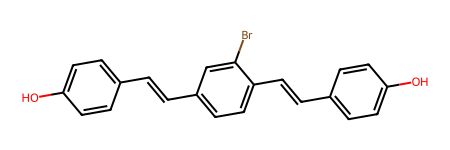

  trans-piceid: 0.3846 (Categories: antioxidant)


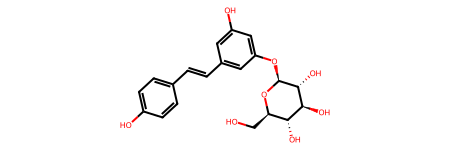

  2',4,4',6'-tetrahydroxychalcone: 0.3600 (Categories: anti_inflammatory_agent)


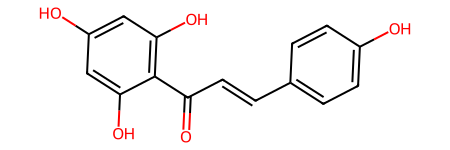

  4-coumaric acid methyl ester: 0.3478 (Categories: anti_inflammatory_agent)


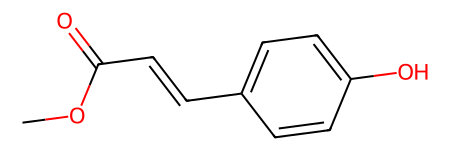

  2',4,4',6'-tetrahydroxychalcone(1-): 0.3214 (Categories: anti_inflammatory_agent)


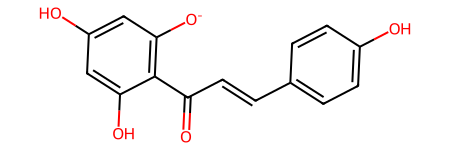

  hydroquinone: 0.3000 (Categories: antioxidant)


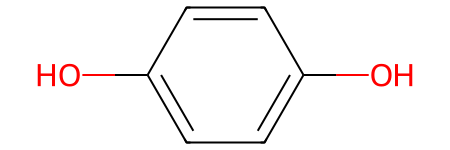

  1,7-bis-(4-hydroxyphenyl)-2,4,6-heptatrienone: 0.2909 (Categories: antioxidant)


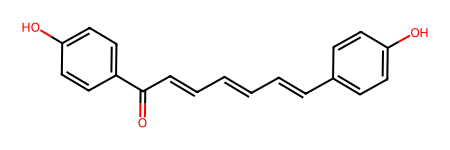

  (E)-trans-miyabenol C: 0.2750 (Categories: antioxidant)


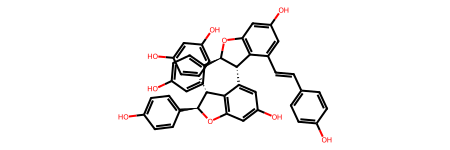

In [77]:
# Get fingerprints and load model
input_path = "data/train_df2.pkl"
fingerprint_objects = fin2(train_df, radius=3, fpSize=4096)
tanimoto_similarity_output(input_path, fingerprint_objects, "resveratrol", 10)

!!!類似度マトリックス！！！

In [88]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
#fp doc2vec
input_path = "data/train_df2.pkl"
with open(input_path, "rb") as f:
    df = pickle.load(f)
model_path = "train_df_doc2vec.model"
bit_list = fin(df, 3, 4096)[1]
compound_vec = make_doc2vector(model_path, df, bit_list)
fpsimilarity_matrix = cosine_similarity(compound_vec)
fpsimilarity_matrix.shape

(3533, 3533)

In [52]:
#name doc2vec
input_path = "data/train_df2.pkl"
with open(input_path, "rb") as f:
    df = pickle.load(f)
model_path = "train_df_namedoc2vec.model"
model = Doc2Vec.load(model_path)
bit_list = fin(df, 3, 4096)[1]
compound_vec = np.array([model.dv.vectors[i] for i in range(len(df))])
namesimilarity_matrix = cosine_similarity(compound_vec)
namesimilarity_matrix.shape

(3533, 3533)

In [53]:
#ECFP
input_path = "data/train_df2.pkl"
with open(input_path, "rb") as f:
    df = pickle.load(f)
ecfp = fin(df, 3, 4096)[0]
ecfpsimilarity_matrix = cosine_similarity(ecfp)
ecfpsimilarity_matrix.shape

(3533, 3533)

In [54]:
#descriptors
input_path = "data/train_df2.pkl"
with open(input_path, "rb") as f:
    df = pickle.load(f)
input_path2 = "data/10genre_32descriptor.pkl"
desc = make_descriptors(input_path2, df)[0]
desc_similarity_matrix = cosine_similarity(desc)
desc_similarity_matrix.shape

(3533, 3533)

In [57]:
def export_upper_triangle_matrix(similarity_matrix, filename):
    n = len(similarity_matrix)
    upper_matrix = np.full((n, n), np.nan)

    for i in range(n):
        for j in range(i, n):
            upper_matrix[i, j] = similarity_matrix[i, j]
    
    df = pd.DataFrame(
        upper_matrix,
        index=[f"cmp_{i}" for i in range(n)],
        columns=[f"cmp_{i}" for i in range(n)]
    )
    
    df.to_excel(filename, index=False, float_format='%.6f')
    return df

In [58]:
a = export_upper_triangle_matrix(fpsimilarity_matrix, "Result/similarity_matrix_fpdoc.xlsx")
a

,cmp_0,cmp_1,cmp_2,cmp_3,cmp_4,cmp_5,cmp_6,cmp_7,cmp_8,cmp_9,...,cmp_3523,cmp_3524,cmp_3525,cmp_3526,cmp_3527,cmp_3528,cmp_3529,cmp_3530,cmp_3531,cmp_3532
cmp_0,1.0,0.43355,0.223046,0.252281,0.374386,0.291753,0.263523,0.266990,0.278363,0.351109,...,0.371949,0.196498,0.369962,0.451215,0.355541,0.327782,0.576048,0.250541,0.167447,0.239587
cmp_1,NaN,1.00000,0.325654,0.400899,0.329056,0.382421,0.472768,0.426155,0.296240,0.256886,...,0.321814,0.363239,0.475340,0.418116,0.463062,0.344039,0.686818,0.315315,0.210311,0.482582
cmp_2,NaN,NaN,1.000000,0.549444,0.237417,0.328338,0.437193,0.545012,0.321417,0.470267,...,0.258596,0.187682,0.293494,0.257159,0.341835,0.345607,0.268862,0.154400,0.443305,0.226200
cmp_3,NaN,NaN,NaN,1.000000,0.337047,0.259661,0.496673,0.736405,0.560410,0.721937,...,0.371880,0.329599,0.444908,0.490823,0.289151,0.271562,0.364502,0.238571,0.243993,0.336078
cmp_4,NaN,NaN,NaN,NaN,1.000000,0.302958,0.246669,0.374451,0.414427,0.299506,...,0.344393,0.294790,0.354219,0.589763,0.476712,0.248918,0.406079,0.216226,0.321418,0.540940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cmp_3528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,0.340462,0.462094,0.213690,0.321877
cmp_3529,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.208429,0.238335,0.438405
cmp_3530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.341967,0.472694
cmp_3531,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.276104


In [59]:
b = export_upper_triangle_matrix(namesimilarity_matrix, "Result/similarity_matrix_namedoc.xlsx")
b

,cmp_0,cmp_1,cmp_2,cmp_3,cmp_4,cmp_5,cmp_6,cmp_7,cmp_8,cmp_9,...,cmp_3523,cmp_3524,cmp_3525,cmp_3526,cmp_3527,cmp_3528,cmp_3529,cmp_3530,cmp_3531,cmp_3532
cmp_0,1.0,0.401497,0.385338,0.396732,0.494027,0.320642,0.426408,0.305411,0.334102,0.316729,...,0.380437,0.349657,0.413632,0.509998,0.319992,0.287046,0.392298,0.274968,0.447100,0.504422
cmp_1,NaN,1.000000,0.363042,0.443664,0.310836,0.150339,0.408976,0.376598,0.362986,0.318821,...,0.463499,0.245744,0.407385,0.286201,0.242783,0.331250,0.364840,0.239538,0.474358,0.443552
cmp_2,NaN,NaN,1.000000,0.402854,0.247175,0.288316,0.531308,0.215390,0.273722,0.266825,...,0.313813,0.343368,0.364015,0.310948,0.474695,0.336368,0.355163,0.292974,0.365525,0.208557
cmp_3,NaN,NaN,NaN,1.000000,0.286009,0.213627,0.334751,0.423027,0.525571,0.450349,...,0.362119,0.448648,0.450938,0.451694,0.324619,0.274209,0.469781,0.433946,0.457910,0.411502
cmp_4,NaN,NaN,NaN,NaN,1.000000,0.277714,0.276113,0.350976,0.300041,0.242790,...,0.303117,0.219501,0.323266,0.521284,0.256974,0.181164,0.246866,0.232714,0.192043,0.359033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cmp_3528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,0.357037,0.314376,0.338850,0.250924
cmp_3529,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.344949,0.377233,0.293989
cmp_3530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.444324,0.470992
cmp_3531,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.313846


In [60]:
c = export_upper_triangle_matrix(ecfpsimilarity_matrix, "Result/similarity_matrix_ecfp.xlsx")
c

,cmp_0,cmp_1,cmp_2,cmp_3,cmp_4,cmp_5,cmp_6,cmp_7,cmp_8,cmp_9,...,cmp_3523,cmp_3524,cmp_3525,cmp_3526,cmp_3527,cmp_3528,cmp_3529,cmp_3530,cmp_3531,cmp_3532
cmp_0,1.0,0.094868,0.079212,0.127289,0.067135,0.110680,0.076200,0.123744,0.100000,0.149003,...,0.158519,0.122474,0.096699,0.200000,0.142887,0.090536,0.217732,0.121268,0.097014,0.100000
cmp_1,NaN,1.000000,0.125245,0.125789,0.000000,0.100000,0.160644,0.195656,0.052705,0.085671,...,0.071611,0.129099,0.101929,0.079057,0.161374,0.085890,0.215166,0.115045,0.076696,0.052705
cmp_2,NaN,NaN,1.000000,0.283579,0.116328,0.172212,0.226348,0.297560,0.165025,0.201184,...,0.112112,0.121268,0.143619,0.115517,0.181902,0.143430,0.107794,0.120073,0.240146,0.132020
cmp_3,NaN,NaN,NaN,1.000000,0.146876,0.138368,0.181865,0.407844,0.251926,0.431056,...,0.162142,0.162392,0.141037,0.198889,0.162392,0.129647,0.086609,0.115771,0.173656,0.159111
cmp_4,NaN,NaN,NaN,NaN,1.000000,0.079612,0.063946,0.103843,0.139864,0.113673,...,0.114022,0.034259,0.121722,0.237768,0.068519,0.060781,0.068519,0.040706,0.122119,0.195809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cmp_3528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,0.123204,0.131749,0.131749,0.105625
cmp_3529,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.132020,0.132020,0.068041
cmp_3530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.147059,0.101057
cmp_3531,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.161690


In [61]:
d = export_upper_triangle_matrix(desc_similarity_matrix, "Result/similarity_matrix_desc.xlsx")
d

,cmp_0,cmp_1,cmp_2,cmp_3,cmp_4,cmp_5,cmp_6,cmp_7,cmp_8,cmp_9,...,cmp_3523,cmp_3524,cmp_3525,cmp_3526,cmp_3527,cmp_3528,cmp_3529,cmp_3530,cmp_3531,cmp_3532
cmp_0,1.0,-0.011286,-0.154211,-0.431567,-0.247149,0.015322,-0.039116,-0.342694,-0.331604,-0.249630,...,-0.085290,0.034404,-0.113835,-0.137562,0.064521,-0.153770,0.207407,0.076634,0.544017,-0.201850
cmp_1,NaN,1.000000,0.229317,-0.293833,-0.242980,-0.495418,0.460142,0.160584,-0.014626,-0.423353,...,0.328681,0.552482,-0.397528,-0.139251,0.180938,0.093262,0.559237,0.536302,0.407260,-0.222682
cmp_2,NaN,NaN,1.000000,0.307980,-0.430420,-0.290142,0.267451,0.402161,0.188611,-0.151546,...,0.536750,0.459496,-0.558663,-0.065692,0.469778,0.456708,-0.123910,0.637159,0.395548,0.193550
cmp_3,NaN,NaN,NaN,1.000000,-0.056365,0.280721,-0.257925,0.542135,0.496884,0.671358,...,-0.177117,-0.306263,0.064527,0.020880,-0.047089,0.152482,-0.344055,-0.164872,-0.428990,0.285061
cmp_4,NaN,NaN,NaN,NaN,1.000000,-0.058195,-0.090475,-0.279477,-0.329676,-0.114757,...,0.086961,-0.360449,0.571154,0.823663,-0.229576,0.134718,-0.147029,-0.216395,-0.373312,0.526151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cmp_3528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,0.011157,0.447966,0.264370,0.591221
cmp_3529,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.218250,0.491177,-0.292237
cmp_3530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.483003,0.076159
cmp_3531,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,-0.166475


In [82]:
from scipy.stats import pearsonr, spearmanr

def frobenius_distance(A, B):
    A = np.array(A)
    B = np.array(B)
    # 上三角部分のみを取得
    mask = np.triu(np.ones_like(A, dtype=bool))
    A_upper = A[mask]
    B_upper = B[mask]
    return np.linalg.norm(A_upper - B_upper)

def pearson_correlation(A, B):
    A = np.array(A)
    B = np.array(B)
    # 上三角部分のみを取得
    mask = np.triu(np.ones_like(A, dtype=bool))
    A_upper = A[mask]
    B_upper = B[mask]
    return pearsonr(A_upper, B_upper)[0]

def spearman_correlation(A, B):
    A = np.array(A)
    B = np.array(B)
    mask = np.triu(np.ones_like(A, dtype=bool))
    A_upper = A[mask]
    B_upper = B[mask]
    return spearmanr(A_upper, B_upper)[0]

In [83]:
def compare_matrices(a, b, c, d):
    matrices = [a, b, c, d]
    n = 4
    
    frobenius_matrix = np.full((n, n), np.nan)
    pearson_matrix = np.full((n, n), np.nan)
    spearman_matrix = np.full((n, n), np.nan)
    
    for i in range(n):
        for j in range(i, n):
            if i == j:
                frobenius_matrix[i, j] = 0.0
                pearson_matrix[i, j] = 1.0
                spearman_matrix[i, j] = 1.0
            else:
                frobenius_matrix[i, j] = frobenius_distance(matrices[i], matrices[j])
                pearson_matrix[i, j] = pearson_correlation(matrices[i], matrices[j])
                spearman_matrix[i, j] = spearman_correlation(matrices[i], matrices[j])
    
    return frobenius_matrix, pearson_matrix, spearman_matrix

In [84]:
frobenius_matrix, pearson_matrix, spearman_matrix = compare_matrices(a, b, c, d)

In [85]:
frobenius_matrix

array([[   0.        ,  335.77598419,  653.87130974, 1221.04534752],
       [          nan,    0.        ,  684.13208494, 1251.9290162 ],
       [          nan,           nan,    0.        ,  904.61493941],
       [          nan,           nan,           nan,    0.        ]])

In [86]:
pearson_matrix

array([[1.        , 0.26861605, 0.64326311, 0.25881545],
       [       nan, 1.        , 0.16929925, 0.11964774],
       [       nan,        nan, 1.        , 0.30464442],
       [       nan,        nan,        nan, 1.        ]])

In [87]:
spearman_matrix

array([[1.        , 0.2143045 , 0.57509982, 0.21719448],
       [       nan, 1.        , 0.07217373, 0.09431372],
       [       nan,        nan, 1.        , 0.25587798],
       [       nan,        nan,        nan, 1.        ]])

In [92]:
def rank_correlation_clustering(similarity_matrices, labels=['Fp Doc2Vec', 'Name Doc2vec', 'ECFP', 'Descriptors']):
    n_compounds = similarity_matrices[0].shape[0]
    n_descriptors = len(similarity_matrices)
    
    # DataFrameをnumpy配列に変換
    matrices = [np.array(matrix) for matrix in similarity_matrices]
    
    # 各参照化合物でのランク相関を計算
    all_correlations = []
    
    for ref_idx in range(n_compounds):
        # 各記述子での順位計算
        ranks = []
        for matrix in matrices:
            similarities = matrix[ref_idx, :]  # 今度はnumpy配列なのでOK
            rank = (-similarities).argsort().argsort()  # 降順ランク
            ranks.append(rank)
        
        # 記述子間のランク相関
        corr_matrix = np.zeros((n_descriptors, n_descriptors))
        for i in range(n_descriptors):
            for j in range(n_descriptors):
                if i == j:
                    corr_matrix[i, j] = 1.0
                else:
                    corr_matrix[i, j] = spearmanr(ranks[i], ranks[j])[0]
        
        all_correlations.append(corr_matrix)
    
    # 平均ランク相関
    avg_correlation = np.mean(all_correlations, axis=0)
    
    # 距離行列と階層的クラスタリング
    distance_matrix = 1 - np.abs(avg_correlation)
    linkage_matrix = linkage(squareform(distance_matrix), method='average')
    
    # 可視化
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    sns.heatmap(avg_correlation, annot=True, cmap='RdBu_r', center=0, 
                xticklabels=labels, yticklabels=labels, ax=ax1)
    ax1.set_title('Average Rank Correlations')
    
    dendrogram(linkage_matrix, labels=labels, ax=ax2)
    ax2.set_title('Hierarchical Clustering')
    
    plt.tight_layout()
    plt.show()
    
    return avg_correlation, linkage_matrix

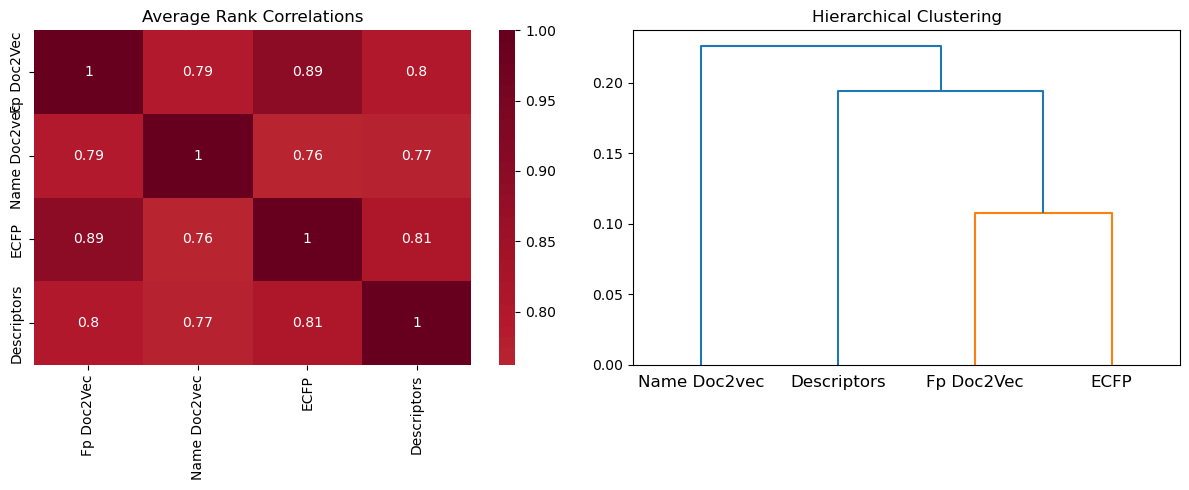

In [93]:
avg_corr, linkage_mat = rank_correlation_clustering([a, b, c, d])

In [94]:
avg_corr

array([[1.        , 0.79165971, 0.89229808, 0.79999213],
       [0.79165971, 1.        , 0.76212851, 0.76860478],
       [0.89229808, 0.76212851, 1.        , 0.81120326],
       [0.79999213, 0.76860478, 0.81120326, 1.        ]])

In [95]:
linkage_mat

array([[0.        , 2.        , 0.10770192, 2.        ],
       [3.        , 4.        , 0.1944023 , 3.        ],
       [1.        , 5.        , 0.225869  , 4.        ]])

In [4]:
input_path = "data/train_df2.pkl"
with open(input_path, "rb") as f:
    train_df = pickle.load(f)
train_df.to_csv("a.csv", index=False)

！！！エンドポイント削除！！！

In [24]:
categories = [
        'antioxidant', 'anti-inflammatory', 'allergen', 'dye', 'toxin', 
        'flavouring', 'agrochemical', 'volatile', 'antibacterial', 'insecticide'
    ]

input_path = "data/train_df2.pkl"
with open(input_path, "rb") as f:
    train_df = pickle.load(f)

purpose_description = "description_gensim"
corpus = train_df[purpose_description].tolist()
for category in categories:
    num =0
    # for i in corpus:
    #     if category in i:
    #         num += 1
    for doc in corpus:  # docは単語のリスト
        if any(category in word for word in doc):
            num += 1 
    print(num)

342
581
277
413
159
145
400
145
544
237


In [25]:
input_path = "data/train_df2.pkl"
with open(input_path, "rb") as f:
    train_df = pickle.load(f)

remove_categories = [
        'antioxidant', 'anti-inflammatory', 'allergen', 'dye', 'toxin', 
        'flavouring', 'agrochemical', 'volatile', 'antibacterial', 'insecticide'
    ]

purpose_description = "description_gensim"
corpussss = train_df[purpose_description].tolist()
for corpus in corpussss:
    # 削除する単語を収集
    words_to_remove = []
    for word in corpus:
        for del_word in remove_categories:
            if del_word in word:
                words_to_remove.append(word)
                break  # 1つ見つかったら次の単語へ

    # 収集した単語を削除
    for word in words_to_remove:
        corpus.remove(word)
corpussss

[['(-)-epicatechin',
  'catechin',
  '(2r,3r)-configuration',
  'role',
  'polyphenol',
  'catechin',
  'enantiomer',
  '(+)-epicatechin'],
 ['2,6-dichlorobenzonitrile',
  'nitrile',
  'benzonitrile',
  'substituted',
  'chlorines',
  'positions',
  '2',
  '6',
  'cellulose',
  'synthesis',
  'inhibitor,',
  'pre-emergent',
  'early',
  'post-emergent',
  'herbicide',
  'role',
  'herbicide,',
  'cellulose',
  'synthesis',
  'inhibitor,',
  'xenobiotic',
  'environmental',
  'contaminant',
  'nitrile',
  'dichlorobenzene',
  'functionally_related',
  'benzonitrile'],
 ['aspartame',
  'dipeptide',
  'obtained',
  'formal_condensation',
  'alpha-carboxy',
  'group',
  'l-aspartic',
  'acid',
  'amino',
  'group',
  'methyl',
  'l-phenylalaninate',
  'commonly',
  'artificial',
  'sweetener',
  'role',
  'sweetening',
  'agent,',
  'nutraceutical,',
  'micronutrient,',
  'xenobiotic,',
  'environmental',
  'contaminant,',
  'apoptosis',
  'inhibitor',
  'ec',
  '3.1.3.1',
  '(alkaline',
 

In [26]:
for category in categories:
    num =0
    # for i in corpus:
    #     if category in i:
    #         num += 1
    for doc in corpus:  # docは単語のリスト
        if any(category in word for word in doc):
            num += 1 
    print(num)

0
0
0
0
0
0
0
0
0
0


In [27]:
def calculate_metrics(y_true, y_pred, y_proba):

    metrics = {}
    metrics['f1'] = f1_score(y_true, y_pred)
    metrics['mcc'] = matthews_corrcoef(y_true, y_pred)
    metrics['balanced_accuracy'] = balanced_accuracy_score(y_true, y_pred)
    metrics['roc_auc'] = roc_auc_score(y_true, y_proba)
    metrics['kappa'] = cohen_kappa_score(y_true, y_pred)
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    metrics['pr_auc'] = auc(recall, precision)
    return metrics

def evaluate_category(category: str, 
                      X_vec: np.ndarray, 
                      y: np.ndarray, 
                      lightgbm_model
                      ) -> Dict[str, Union[List[float], float]]:
    
    # 全ての評価指標のスコアを格納する辞書
    all_train_scores = {'f1': [], 'mcc': [], 'balanced_accuracy': [], 'roc_auc': [], 'kappa': [], 'pr_auc': []}
    all_test_scores = {'f1': [], 'mcc': [], 'balanced_accuracy': [], 'roc_auc': [], 'kappa': [], 'pr_auc': []}


    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    for train_idx, test_idx in skf.split(range(len(y)), y):
        X_train_vec, X_test_vec = X_vec[train_idx], X_vec[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        lightgbm_model.fit(X_train_vec, y_train)
        y_train_pred = lightgbm_model.predict(X_train_vec)
        y_test_pred = lightgbm_model.predict(X_test_vec)
        y_train_proba = lightgbm_model.predict_proba(X_train_vec)[:, 1]
        y_test_proba = lightgbm_model.predict_proba(X_test_vec)[:, 1]

        train_metrics = calculate_metrics(y_train, y_train_pred, y_train_proba)
        test_metrics = calculate_metrics(y_test, y_test_pred, y_test_proba)
        for metric_name in all_train_scores.keys():
            all_train_scores[metric_name].append(train_metrics[metric_name])
            all_test_scores[metric_name].append(test_metrics[metric_name])
    
    # 結果を整理
    results = {}
    for metric_name in all_train_scores.keys():
        results[metric_name] = {
            'train_scores': all_train_scores[metric_name],
            'test_scores': all_test_scores[metric_name],
            'mean_train': np.mean(all_train_scores[metric_name]),
            'mean_test': np.mean(all_test_scores[metric_name])
        }
    
    return results

def build_fpdoc2vec_model(corpus: List[List[str]], 
                        tag_list: List[List[int]], #変更
                        doc2vec_param: Dict[str, Any]) -> Doc2Vec:
    """
    Build and train a Doc2Vec model from corpus and structure information
    
    Args:
        corpus: List of lists containing tokenized text for each document
        list: List of lists containing tags for each document
        doc2vec_param: Dictionary of parameters for the Doc2Vec model
        
    Returns:
        Trained Doc2Vec model
    """
    tagged_documents = [
        TaggedDocument(words=corpus, tags=tag_list[i]) #変更
        for i, corpus in enumerate(corpus)
    ]
    
    model = Doc2Vec(tagged_documents, **doc2vec_param)
    
    return model

def make_doc2vector(df: pd.DataFrame, purpose_description: str, tag_list: List[List[int]], doc2vec_param: Dict[str, Any]) -> np.ndarray:

    corpus = df[purpose_description].tolist()#変更
    model = build_fpdoc2vec_model(corpus, tag_list, doc2vec_param)
    compound_vec = add_vectors(tag_list, model)
    X_vec = np.array([compound_vec[i] for i in range(len(df))])
    return X_vec

def main(df: pd.DataFrame, 
         X_vec: np.ndarray, 
         lightgbm_model) -> Dict[str, Dict[str, float]]:
    """
    Main function to train and evaluate compound classification models using provided features and Doc2Vec.
    
    Args:
        input_path: Path to the pickle file containing compound data
        feature_list: List of molecular features (like fingerprints) to use in the model
        doc2vec_param: Parameters for the Doc2Vec model
        lightgbm_model: Pre-configured LightGBM classifier
        purpose_description: Column name in the DataFrame containing text descriptions
        
    Returns:
        Dictionary mapping category names to evaluation results
    """
        
    # Define categories to evaluate
    categories = [
        'antioxidant', 'anti_inflammatory_agent', 'allergen', 'dye', 'toxin', 
        'flavouring_agent', 'agrochemical', 'volatile_oil', 'antibacterial_agent', 'insecticide'
    ]
    
    # Evaluate each category
    results = {}
    for category in categories:
        y = np.array([1 if i == category else 0 for i in df[category]])
        results[category] = evaluate_category(category, X_vec, y, lightgbm_model)

    return results

In [28]:
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

doc2vec_param: Dict[str, Any] = {
    'vector_size': 150,
    'dm': 1,
    'window': 9,
    'min_count': 0,
    'alpha': 0.014996471116783728,
    'sample': 4.4713728630733355e-05,
    'epochs': 840,
    'negative': 12,
    'workers': 1,
    'seed': 0
}

gbm_params: Dict[str, Any] = {
    "boosting_type": "dart",
    "num_leaves": 48,
    "max_depth": 5,
    "learning_rate": 0.04166324251391809,
    "n_estimators": 736,
    "class_weight": "balanced",
    "min_split_gain": 0.009346925180781129,
    "min_child_weight": 0.0007929549087822909,
    "min_child_samples": 37,
    "reg_alpha": 1.757104268180148,
    "reg_lambda": 1.463369722508726,
    "feature_fraction": 0.50163362868711,
    "feature_fraction_bynode": 0.8321043377994284,
    "subsample": 0.6974385909748512,
    "colsample_bytree": 0.6568268046410831,
    "subsample_freq": 5,
    "drop_rate": 0.24668126335938073,
    "max_drop": 28,
    "skip_drop": 0.5591506516119614,
    "uniform_drop": True,
    "xgboost_dart_mode": True,
    "objective": "binary",
    "random_state": 0,
    "verbose": -1,
    "force_col_wise": True
}

# Create classifier
lightgbm_model = lgb.LGBMClassifier(**gbm_params)

# Load dataset for later use
# Example usage - replace with your actual file paths
input_path = "data/train_df2.pkl"
with open(input_path, "rb") as f:
    df = pickle.load(f)
# remove_categories = ['antioxidant', 'anti-inflammatory_agent', 'allergen', 'dye', 'toxin', 
#                      'flavouring', 'agrochemical', 'volatile_oil', 'antibacterial_agent', 'insecticide']

# corpussss = train_df[purpose_description].tolist()
# for corpus in corpussss:
#     for del_word in remove_categories:
#         while del_word in corpus:
#             corpus.remove(del_word)
df["description_gensim"] = corpussss
# FP Doc2Vec approach
fp4096_list, bit_list = fin(df, 3, 4096)
X_vec = make_doc2vector(df, "description_gensim", bit_list, doc2vec_param)
results4096 = main(df, X_vec, lightgbm_model)

In [30]:
categories = [
        'antioxidant', 'anti_inflammatory_agent', 'allergen', 'dye', 'toxin', 
        'flavouring_agent', 'agrochemical', 'volatile_oil', 'antibacterial_agent', 'insecticide'
    ]
li = []
for category, result in results4096.items():
    print(f"## {category} ##")
    print(results4096[category]['f1']["mean_test"])
    li.append(results4096[category]['f1']["mean_test"])
print("")
print(np.mean(li))

## antioxidant ##
0.7003446447804499
## anti_inflammatory_agent ##
0.722538053930497
## allergen ##
0.6632414853350315
## dye ##
0.9344625178021195
## toxin ##
0.605644234992061
## flavouring_agent ##
0.6790619148293567
## agrochemical ##
0.8050100880633078
## volatile_oil ##
0.8037594164030946
## antibacterial_agent ##
0.66842242508206
## insecticide ##
0.7551595585355176

0.7337644339753495


In [31]:
with open("result_full_prediction/___delendpoint_fpdoc2vec.pkl", "wb") as f:
    pickle.dump(results4096, f)


！！！Name doc2vec !!!

In [32]:
input_path = "data/train_df2.pkl"
with open(input_path, "rb") as f:
    df = pickle.load(f)
df["description_gensim"] = corpussss
X_vec = make_name2vector(df, "description_gensim", doc2vec_param)
resultsname = main(df, X_vec, lightgbm_model)

In [33]:
categories = [
        'antioxidant', 'anti_inflammatory_agent', 'allergen', 'dye', 'toxin', 
        'flavouring_agent', 'agrochemical', 'volatile_oil', 'antibacterial_agent', 'insecticide'
    ]
li = []
for category, result in resultsname.items():
    print(f"## {category} ##")
    print(resultsname[category]['f1']["mean_test"])
    li.append(resultsname[category]['f1']["mean_test"])
print("")
print(np.mean(li))

## antioxidant ##
0.6189278303752903
## anti_inflammatory_agent ##
0.6524988358566038
## allergen ##
0.6702737208401615
## dye ##
0.9024823882262677
## toxin ##
0.5026197458455524
## flavouring_agent ##
0.6170668875116457
## agrochemical ##
0.7400392265351465
## volatile_oil ##
0.7873461768900366
## antibacterial_agent ##
0.6148639232937115
## insecticide ##
0.7132382531081294

0.6819356988482546


In [34]:
with open("result_full_prediction/___delendpoint_namedoc2vec.pkl", "wb") as f:
    pickle.dump(resultsname, f)

In [97]:
import random

!!!文章入れ替え！！！

In [ ]:
import random

input_path = "data/train_df2.pkl"
with open(input_path, "rb") as f:
    df = pickle.load(f)

random.seed(0)
corpus = df["description_gensim"].tolist()
random.shuffle(corpus)
df["description_gensim"] = corpus

# FP Doc2Vec approach
fp4096_list, bit_list = fin(df, 3, 4096)
X_vec = make_doc2vector(df, "description_gensim", bit_list, doc2vec_param)
shuffle_results4096 = main(df, X_vec, lightgbm_model)

In [78]:
categories = [
        'antioxidant', 'anti_inflammatory_agent', 'allergen', 'dye', 'toxin', 
        'flavouring_agent', 'agrochemical', 'volatile_oil', 'antibacterial_agent', 'insecticide'
    ]
li = []
for category, result in shuffle_results4096.items():
    print(f"## {category} ##")
    print(shuffle_results4096[category]['f1']["mean_test"])
    li.append(shuffle_results4096[category]['f1']["mean_test"])
print("")
print(np.mean(li))

## antioxidant ##
0.6350164041643108
## anti_inflammatory_agent ##
0.6323691299865914
## allergen ##
0.6046873379202229
## dye ##
0.8968862476416408
## toxin ##
0.5212923620789287
## flavouring_agent ##
0.6267705387033804
## agrochemical ##
0.7062510245548245
## volatile_oil ##
0.7936472929576379
## antibacterial_agent ##
0.5660056937904263
## insecticide ##
0.674343302667919

0.6657269334465883


In [102]:
categories = [
        'antioxidant', 'anti_inflammatory_agent', 'allergen', 'dye', 'toxin', 
        'flavouring_agent', 'agrochemical', 'volatile_oil', 'antibacterial_agent', 'insecticide'
    ]
li = []
for category, result in shuffle_results4096.items():
    print(f"## {category} ##")
    print(shuffle_results4096[category]['f1']["mean_test"])
    li.append(shuffle_results4096[category]['f1']["mean_test"])
print("")
print(np.mean(li))

## antioxidant ##
0.030433872561239878
## anti_inflammatory_agent ##
0.09657921544720155
## allergen ##
0.033681716001122755
## dye ##
0.08936931366625796
## toxin ##
0.0
## flavouring_agent ##
0.0
## agrochemical ##
0.045870669051063566
## volatile_oil ##
0.0
## antibacterial_agent ##
0.09141428233649422
## insecticide ##
0.0

0.038734906906338


In [74]:
with open("result_full_prediction/___shuffle_fpdoc2vec.pkl", "wb") as f:
    pickle.dump(shuffle_results4096, f)

In [103]:
with open("result_full_prediction/___shuffle_namedoc2vec.pkl", "wb") as f:
    pickle.dump(shuffle_results4096, f)

!!!文章の単語前後関係入れ替え！！！

In [11]:
import random
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

In [17]:
doc2vec_param: Dict[str, Any] = {
    'vector_size': 150,
    'dm': 1,
    'window': 9,
    'min_count': 0,
    'alpha': 0.014996471116783728,
    'sample': 4.4713728630733355e-05,
    'epochs': 840,
    'negative': 12,
    'workers': 1,
    'seed': 0
}

input_path = "data/train_df2.pkl"
with open(input_path, "rb") as f:
    df = pickle.load(f)

corpus = df["description_gensim"].tolist()
random.seed(0)
for i in corpus:
    random.shuffle(i)
df["description_gensim"] = corpus 

gbm_params: Dict[str, Any] = {
    "boosting_type": "dart",
    "num_leaves": 48,
    "max_depth": 5,
    "learning_rate": 0.04166324251391809,
    "n_estimators": 736,
    "class_weight": "balanced",
    "min_split_gain": 0.009346925180781129,
    "min_child_weight": 0.0007929549087822909,
    "min_child_samples": 37,
    "reg_alpha": 1.757104268180148,
    "reg_lambda": 1.463369722508726,
    "feature_fraction": 0.50163362868711,
    "feature_fraction_bynode": 0.8321043377994284,
    "subsample": 0.6974385909748512,
    "colsample_bytree": 0.6568268046410831,
    "subsample_freq": 5,
    "drop_rate": 0.24668126335938073,
    "max_drop": 28,
    "skip_drop": 0.5591506516119614,
    "uniform_drop": True,
    "xgboost_dart_mode": True,
    "objective": "binary",
    "random_state": 0,
    "verbose": -1,
    "force_col_wise": True
}

# Create classifier
lightgbm_model = lgb.LGBMClassifier(**gbm_params)

# FP Doc2Vec approach
fp4096_list, bit_list = fin(df, 3, 4096)
X_vec = make_doc2vector(df, "description_gensim", bit_list, doc2vec_param)
shuffle_results4096 = main(df, X_vec, lightgbm_model)

In [18]:
categories = [
        'antioxidant', 'anti_inflammatory_agent', 'allergen', 'dye', 'toxin', 
        'flavouring_agent', 'agrochemical', 'volatile_oil', 'antibacterial_agent', 'insecticide'
    ]
li = []
for category, result in shuffle_results4096.items():
    print(f"## {category} ##")
    print(shuffle_results4096[category]['f1']["mean_test"])
    li.append(shuffle_results4096[category]['f1']["mean_test"])
print("")
print(np.mean(li))

## antioxidant ##
0.7301980290043006
## anti_inflammatory_agent ##
0.7668484205271937
## allergen ##
0.7022436846074784
## dye ##
0.9369984876182759
## toxin ##
0.6310793835015094
## flavouring_agent ##
0.6851592886811579
## agrochemical ##
0.8166689460721326
## volatile_oil ##
0.8012367169764278
## antibacterial_agent ##
0.7216661868713719
## insecticide ##
0.7890755602387108

0.7581174704098559


In [19]:
with open("result_full_prediction/___wordshuffle_fpdoc2vec.pkl", "wb") as f:
    pickle.dump(shuffle_results4096, f)

In [20]:
def make_name2vector(df: pd.DataFrame, purpose_description, doc2vec_param) -> np.ndarray:
    corpus = df[purpose_description].tolist()#変更
    tag_list = [i[0] for i in df["compounds"]]

    tagged_documents = [TaggedDocument(words=corpus, tags=[tag_list[i]]) #変更
        for i, corpus in enumerate(corpus)]
    model = Doc2Vec(tagged_documents, **doc2vec_param)
    X_vec = np.array([model.dv.vectors[i] for i in range(len(df))])

    return X_vec

In [21]:
X_vec = make_name2vector(df, "description_gensim", doc2vec_param)
shuffle_resultsname = main(df, X_vec, lightgbm_model)

In [22]:
for category, result in shuffle_resultsname.items():
    print(f"## {category} ##")
    print(shuffle_resultsname[category]['f1']["mean_test"])
    li.append(shuffle_resultsname[category]['f1']["mean_test"])
print("")
print(np.mean(li))

## antioxidant ##
0.7632488151183259
## anti_inflammatory_agent ##
0.8013772111421966
## allergen ##
0.8211746453900709
## dye ##
0.9288175801456029
## toxin ##
0.6598873463840266
## flavouring_agent ##
0.7875702739289696
## agrochemical ##
0.8255705547161378
## volatile_oil ##
0.8418803418803419
## antibacterial_agent ##
0.7703935792032678
## insecticide ##
0.804105390248518

0.7792600221128008


In [23]:
with open("result_full_prediction/___wordshuffle_namedoc2vec.pkl", "wb") as f:
    pickle.dump(shuffle_resultsname, f)

！！！説明文の長さ！！！

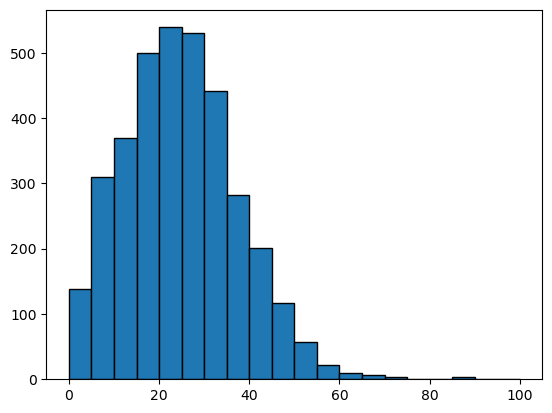

In [10]:
input_path = "data/train_df2.pkl"
with open(input_path, "rb") as f:
    df = pickle.load(f)

corpus = df["description_gensim"].tolist()
data = [len(i) for i in corpus]
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.hist(data, bins=[i for i in range(0, max(data)+1, 5)], histtype='barstacked', ec='black')
plt.show()

In [ ]:
input_path = "Result/fpdoc2vec.pkl"
with open(input_path, "rb") as f:
    a = pickle.load(f)

In [46]:
li = []
for category, result in a.items():
    print(f"## {category} ##")
    print(a[category]['f1']["test_scores"])
    li.append(a[category]['f1']["test_scores"])
print("")
print(li)

## antioxidant ##
[0.7027027027027027, 0.7431693989071039, 0.7403314917127072, 0.7283236994219653, 0.6961325966850829]
## anti_inflammatory_agent ##
[0.7346938775510204, 0.7615062761506276, 0.796812749003984, 0.6666666666666666, 0.7741935483870968]
## allergen ##
[0.59375, 0.7222222222222222, 0.7761194029850746, 0.6825396825396826, 0.6818181818181818]
## dye ##
[0.9416666666666667, 0.9451476793248945, 0.9177489177489178, 0.935064935064935, 0.9531914893617022]
## toxin ##
[0.5833333333333334, 0.5866666666666667, 0.6060606060606061, 0.7105263157894737, 0.6571428571428571]
## flavouring_agent ##
[0.7435897435897436, 0.759493670886076, 0.7575757575757576, 0.717948717948718, 0.6746987951807228]
## agrochemical ##
[0.7845303867403315, 0.8478260869565217, 0.8, 0.8323699421965318, 0.8128342245989305]
## volatile_oil ##
[0.8539325842696629, 0.7733333333333333, 0.8444444444444444, 0.8085106382978723, 0.7317073170731707]
## antibacterial_agent ##
[0.7088607594936709, 0.6967213114754098, 0.7295081

In [11]:
import pandas as pd
input_path = "Result/result_4compare.csv"
df = pd.read_csv(input_path, encoding='shift_jis')
df.columns

Index(['NAME', 'inchikey', 'smiles', 'description', 'antioxidant',
       'fp_doc2vec_antioxidant', 'namedoc_antioxidant', 'ecfp_antioxidant',
       'desc_antioxidant', 'anti_inflammatory_agent',
       'fp_doc2vec_anti_inflammatory_agent', 'namedoc_anti_inflammatory_agent',
       'ecfp_anti_inflammatory_agent', 'desc_anti_inflammatory_agent',
       'allergen', 'fp_doc2vec_allergen', 'namedoc_allergen', 'ecfp_allergen',
       'desc_allergen', 'dye', 'fp_doc2vec_dye', 'namedoc_dye', 'ecfp_dye',
       'desc_dye', 'toxin', 'fp_doc2vec_toxin', 'namedoc_toxin', 'ecfp_toxin',
       'desc_toxin', 'flavouring_agent', 'fp_doc2vec_flavouring_agent',
       'namedoc_flavouring_agent', 'ecfp_flavouring_agent',
       'desc_flavouring_agent', 'agrochemical', 'fp_doc2vec_agrochemical',
       'namedoc_agrochemical', 'ecfp_agrochemical', 'desc_agrochemical',
       'volatile_oil', 'fp_doc2vec_volatile_oil', 'namedoc_volatile_oil',
       'ecfp_volatile_oil', 'desc_volatile_oil', 'antibacterial_

In [39]:
input_path = "data/10genre_all.pkl"
with open(input_path, "rb") as f:
    df = pickle.load(f)

input_path2 = "data/train_df2.pkl"
with open(input_path2, "rb") as f:
    train_df = pickle.load(f)

In [40]:
a=set(train_df["inchikey"])
len(a)

3533

In [42]:
df_SI = pd.DataFrame({
    "NAME": [i[0] for i in df["compounds"]], 
    "SMILES": [i[1] for i in df["compounds"]], 
    "InChIKey": list(df["inchikey"]), 
    "antioxidant": list(df["antioxidant"]),
    "anti_inflammatory_agent": list(df["anti_inflammatory_agent"]), 
    "allergen": list(df["allergen"]), 
    "dye": list(df["dye"]), 
    "toxin": list(df["toxin"]),
    "flavouring_agent": list(df["flavouring_agent"]), 
    "agrochemical": list(df["agrochemical"]), 
    "volatile_oil": list(df["volatile_oil"]),
    "antibacterial_agent": list(df["antibacterial_agent"]), 
    "insecticide": list(df["insecticide"])
})
df_SI["Training or Test"] = ["Training" if i in list(train_df["inchikey"]) else "Test" for i in df_SI["InChIKey"]]
df_SI

,NAME,SMILES,InChIKey,antioxidant,anti_inflammatory_agent,allergen,dye,toxin,flavouring_agent,agrochemical,volatile_oil,antibacterial_agent,insecticide,Training or Test
0,(-)-epicatechin,Oc1cc(O)c2c(c1)O[C@H](c1ccc(O)c(O)c1)[C@H](O)C2,PFTAWBLQPZVEMU-UKRRQHHQSA-N,antioxidant,No,No,No,No,No,No,No,No,No,Training
1,"2,6-dichlorobenzonitrile",N#Cc1c(Cl)cccc1Cl,YOYAIZYFCNQIRF-UHFFFAOYSA-N,No,No,No,No,No,No,agrochemical,No,No,No,Training
2,aspartame,COC(=O)[C@H](Cc1ccccc1)NC(=O)[C@@H](N)CC(=O)O,IAOZJIPTCAWIRG-QWRGUYRKSA-N,No,No,No,No,No,flavouring_agent,No,No,No,No,Training
3,azlocillin,CC1(C)S[C@@H]2[C@H](NC(=O)[C@H](NC(=O)N3CCNC3=...,JTWOMNBEOCYFNV-NFFDBFGFSA-N,No,No,allergen,No,No,No,No,No,antibacterial_agent,No,Training
4,betulinic acid,C=C(C)[C@@H]1CC[C@]2(C(=O)O)CC[C@]3(C)[C@H](CC...,QGJZLNKBHJESQX-FZFNOLFKSA-N,No,anti_inflammatory_agent,No,No,No,No,No,No,No,No,Training
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3921,cefpirome,CO/N=C(\C(=O)N[C@@H]1C(=O)N2C(C(=O)[O-])=C(C[n...,DKOQGJHPHLTOJR-WHRDSVKCSA-N,No,No,allergen,No,No,No,No,No,No,No,Test
3922,corilagin,O=C(O[C@@H]1O[C@@H]2COC(=O)c3cc(O)c(O)c(O)c3-c...,TUSDEZXZIZRFGC-XIGLUPEJSA-N,antioxidant,anti_inflammatory_agent,No,No,No,No,No,No,No,No,Test
3923,gallamine,CCN(CC)CCOc1cccc(OCCN(CC)CC)c1OCCN(CC)CC,ICLWTJIMXVISSR-UHFFFAOYSA-N,No,No,allergen,No,No,No,No,No,No,No,Test
3924,mecarbam,CCOC(=O)N(C)C(=O)CSP(=S)(OCC)OCC,KLGMSAOQDHLCOS-UHFFFAOYSA-N,No,No,No,No,No,No,agrochemical,No,No,insecticide,Test


In [43]:
df_SI.to_csv("data/Dataset.csv", index = False)

In [24]:
df[df["len_gensim"] == 0]

,NAME,inchikey,smiles,description,antioxidant,fp_doc2vec_antioxidant,namedoc_antioxidant,ecfp_antioxidant,desc_antioxidant,anti_inflammatory_agent,...,fp_doc2vec_insecticide,namedoc_insecticide,ecfp_insecticide,desc_insecticide,score,fp_3_4096,len_fp,len_description,description_gensim,len_gensim
